In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Kirti Singh\Downloads\sales_data.csv")
df.head()

,OrderID,Product,Region,Sales,Quantity,Discount
0,1,Laptop,India,50000,2,10
1,2,Phone,USA,30000,3,5
2,3,Tablet,India,20000,1,0
3,4,Monitor,UK,15000,2,8
4,5,Keyboard,India,5000,5,2


In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   OrderID   7 non-null      int64
 1   Product   7 non-null      str  
 2   Region    7 non-null      str  
 3   Sales     7 non-null      int64
 4   Quantity  7 non-null      int64
 5   Discount  7 non-null      int64
dtypes: int64(4), str(2)
memory usage: 468.0 bytes


,OrderID,Sales,Quantity,Discount
count,7.000000,7.000000,7.000000,7.000000
mean,4.000000,20000.000000,2.571429,5.000000
std,2.160247,15588.457268,1.511858,3.559026
min,1.000000,5000.000000,1.000000,0.000000
25%,2.500000,10000.000000,1.500000,2.500000
50%,4.000000,15000.000000,2.000000,5.000000
75%,5.500000,25000.000000,3.500000,7.500000
max,7.000000,50000.000000,5.000000,10.000000


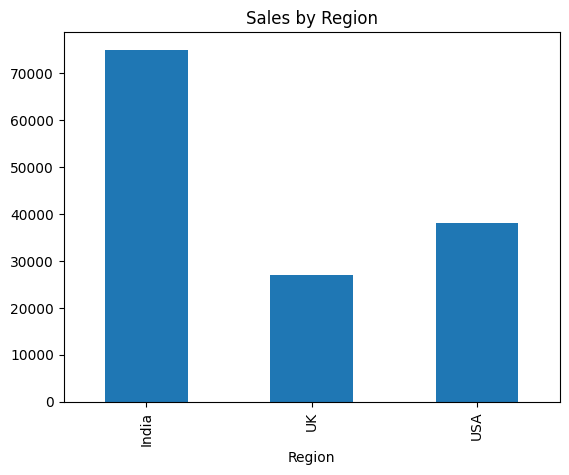

In [6]:
df.groupby("Region")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Region")
plt.show()

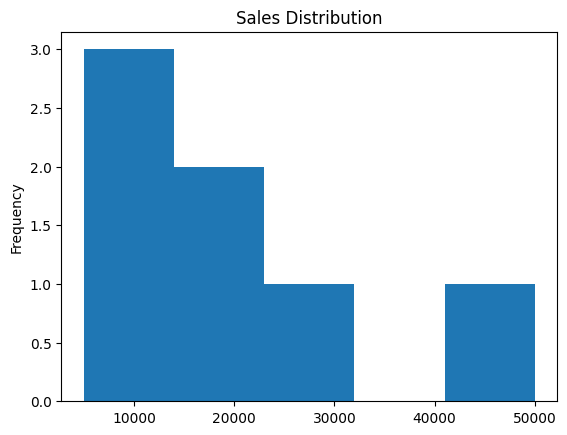

In [7]:
df["Sales"].plot(kind="hist", bins=5)
plt.title("Sales Distribution")
plt.show()

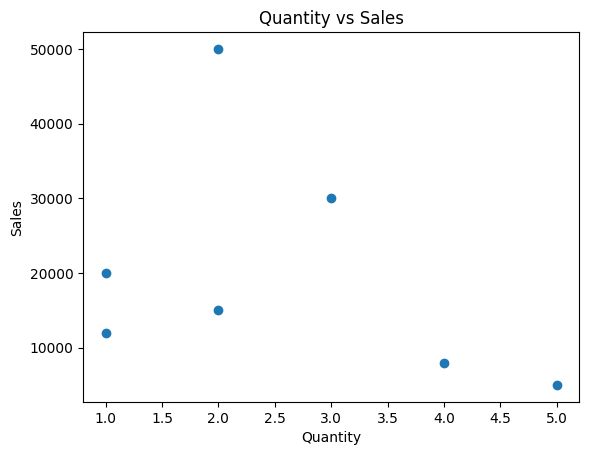

In [8]:
plt.scatter(df["Quantity"], df["Sales"])
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Quantity vs Sales")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Convert categorical → numeric
df_encoded = pd.get_dummies(df, columns=["Product", "Region"], drop_first=True)

# Features & Target
X = df_encoded.drop(["Sales", "OrderID"], axis=1)
y = df_encoded["Sales"]

# Split (important: random_state add karo)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


In [10]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 29409.022177419352
R2 Score: -8.561874545888273


In [11]:
import joblib

joblib.dump(model, "../outputs/model.pkl")

print("Model saved successfully ✅")

Model saved successfully ✅


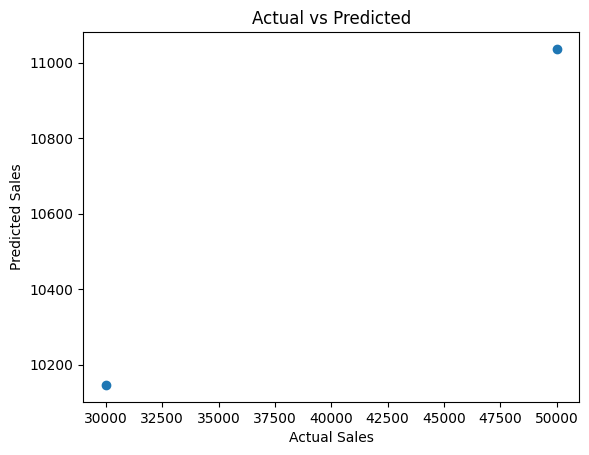

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")

plt.savefig("../outputs/plots/prediction_plot.png")
plt.show()

In [13]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Kirti Singh\Downloads\sales_data.csv")
df.head()

,OrderID,Product,Region,Sales,Quantity,Discount
0,1,Laptop,India,50000,2,10
1,2,Phone,USA,30000,3,5
2,3,Tablet,India,20000,1,0
3,4,Monitor,UK,15000,2,8
4,5,Keyboard,India,5000,5,2
